In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

In [3]:
# phase 1: Load and inspect
print(df.shape)

(891, 15)


In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [8]:
# phase 2: DATA CLEANING
df = df.drop_duplicates()


In [9]:
df["sex"] = df["sex"].str.strip()
df["class"] = df["class"].astype(str).str.strip()
df["embark_town"] = df["embark_town"].str.strip()

In [10]:
df["age"] = df["age"].fillna(df["age"].median())

In [11]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [12]:
df["deck"] = df["deck"].astype(str).replace("nan", "unknown")

In [13]:
df["age"] = df["age"].astype(int)
df["fare"] = df["fare"].astype(float)

In [14]:
df["family_size"] = df["sibsp"] + df["parch"] + 1


In [15]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

In [16]:
df["fare_per_person"] = df["fare"] / df["family_size"]


(array([ 29.,  20.,  18.,  15.,  76.,  75.,  84., 190.,  63.,  53.,  39.,
         34.,  31.,  18.,  13.,  13.,   6.,   5.,   1.,   1.]),
 array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48.,
        52., 56., 60., 64., 68., 72., 76., 80.]),
 <BarContainer object of 20 artists>)

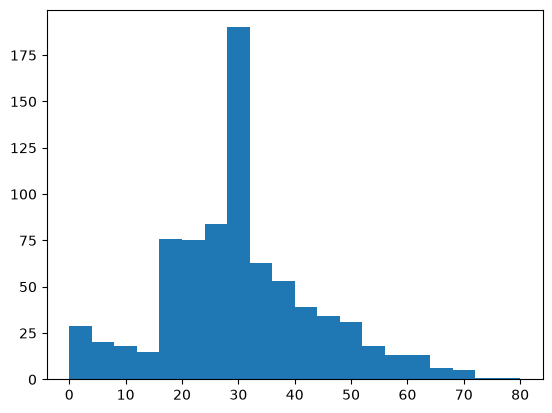

In [17]:
#phase 3: Explore (Charts)
plt.hist(df["age"], bins=20)

<Axes: xlabel='sex'>

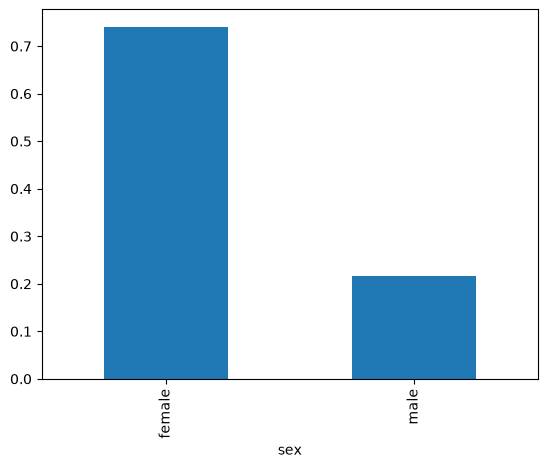

In [18]:
df.groupby("sex")["survived"].mean().plot(kind="bar")

<Axes: >

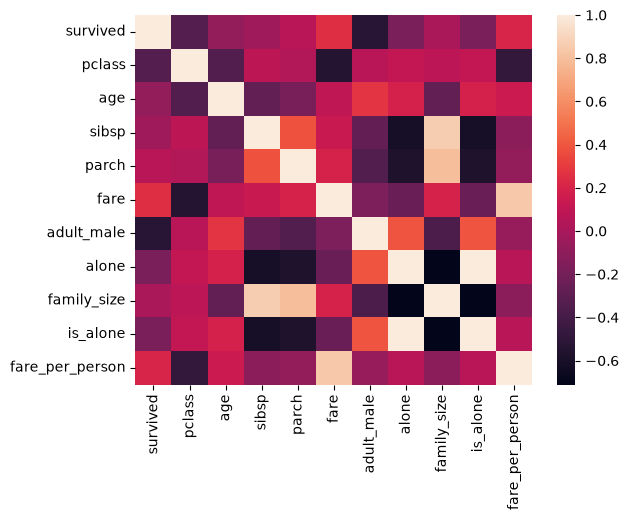

In [19]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='class'>

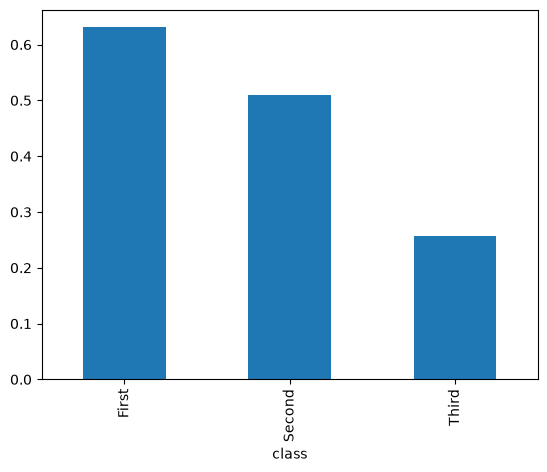

In [20]:
df.groupby("class")["survived"].mean().plot(kind="bar")

In [21]:

df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   sex              784 non-null    str    
 3   age              784 non-null    int64  
 4   sibsp            784 non-null    int64  
 5   parch            784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         782 non-null    str    
 8   class            784 non-null    str    
 9   who              784 non-null    str    
 10  adult_male       784 non-null    bool   
 11  deck             202 non-null    str    
 12  embark_town      784 non-null    str    
 13  alive            784 non-null    str    
 14  alone            784 non-null    bool   
 15  family_size      784 non-null    int64  
 16  is_alone         784 non-null    int64  
 17  fare_per_person  784 non-null   

In [22]:
df.drop(columns=['embark_town','class','alive','deck','alone','who'], inplace= True, errors = 'ignore')

In [23]:
df = pd.get_dummies(df, columns=['sex','embarked','adult_male'], dtype=int)

In [24]:
df.head()


,survived,pclass,age,sibsp,parch,fare,family_size,is_alone,fare_per_person,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,adult_male_False,adult_male_True
0,0,3,22,1,0,7.2500,2,0,3.62500,0,1,0,0,1,0,1
1,1,1,38,1,0,71.2833,2,0,35.64165,1,0,1,0,0,1,0
2,1,3,26,0,0,7.9250,1,1,7.92500,1,0,0,0,1,1,0
3,1,1,35,1,0,53.1000,2,0,26.55000,1,0,0,0,1,1,0
4,0,3,35,0,0,8.0500,1,1,8.05000,0,1,0,0,1,0,1


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   survived          784 non-null    int64  
 1   pclass            784 non-null    int64  
 2   age               784 non-null    int64  
 3   sibsp             784 non-null    int64  
 4   parch             784 non-null    int64  
 5   fare              784 non-null    float64
 6   family_size       784 non-null    int64  
 7   is_alone          784 non-null    int64  
 8   fare_per_person   784 non-null    float64
 9   sex_female        784 non-null    int64  
 10  sex_male          784 non-null    int64  
 11  embarked_C        784 non-null    int64  
 12  embarked_Q        784 non-null    int64  
 13  embarked_S        784 non-null    int64  
 14  adult_male_False  784 non-null    int64  
 15  adult_male_True   784 non-null    int64  
dtypes: float64(2), int64(14)
memory usage: 104.1 KB


In [26]:
print("="*50)
print("DATA CLEANING SUMMARY")
print("="*50)

print("Before Cleaning:")
print("- Rows: 891")
print("- Columns: 15")
print("- Duplicate Records: 107")
print("- Missing Values: 866")

print("\nAfter Cleaning:")
print("- Rows: 784")
print("- Columns: 12")
print("- Duplicate Records: 0")
print("- Missing Values: 0")

print("\nFeature Engineering:")
print("- Added: family_size")
print("- Added: is_alone")
print("- Added: fare_per_person")

print("\nResult:")
print("Dataset is cleaned, missing values handled, duplicates removed,")
print("new features created, and the data is ready for analysis or machine learning.")

DATA CLEANING SUMMARY
Before Cleaning:
- Rows: 891
- Columns: 15
- Duplicate Records: 107
- Missing Values: 866

After Cleaning:
- Rows: 784
- Columns: 12
- Duplicate Records: 0
- Missing Values: 0

Feature Engineering:
- Added: family_size
- Added: is_alone
- Added: fare_per_person

Result:
Dataset is cleaned, missing values handled, duplicates removed,
new features created, and the data is ready for analysis or machine learning.


In [27]:
# Phase 4: Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features (X) and Target (y)
X = df.drop("survived", axis=1)
y = df["survived"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and Train Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8598726114649682

Confusion Matrix:
[[81 11]
 [11 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        92
           1       0.83      0.83      0.83        65

    accuracy                           0.86       157
   macro avg       0.86      0.86      0.86       157
weighted avg       0.86      0.86      0.86       157



In [28]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df)

             Feature  Coefficient
13  adult_male_False     1.132789
8         sex_female     0.184417
10        embarked_C     0.123965
4               fare     0.002362
7    fare_per_person    -0.001338
1                age    -0.024810
3              parch    -0.072433
12        embarked_S    -0.102430
9           sex_male    -0.181088
2              sibsp    -0.191861
5        family_size    -0.260965
11        embarked_Q    -0.286806
6           is_alone    -0.465233
0             pclass    -1.004501
14   adult_male_True    -1.129461


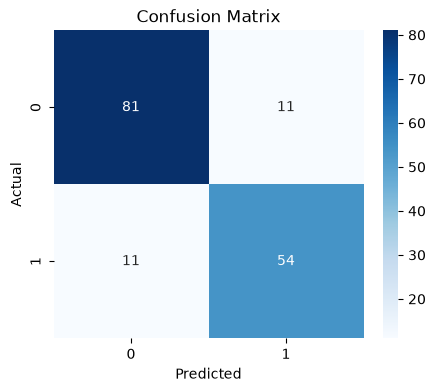

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.show()

In [30]:
# Phase 4: Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
# Features (X) and Target (y)
X = df.drop("survived", axis=1)
y = df["survived"]

In [32]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
# Create and Train Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [34]:
# Predictions
y_pred = model.predict(X_test)

In [35]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8598726114649682


In [36]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[81 11]
 [11 54]]


In [37]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        92
           1       0.83      0.83      0.83        65

    accuracy                           0.86       157
   macro avg       0.86      0.86      0.86       157
weighted avg       0.86      0.86      0.86       157



In [38]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df)

             Feature  Coefficient
13  adult_male_False     1.132789
8         sex_female     0.184417
10        embarked_C     0.123965
4               fare     0.002362
7    fare_per_person    -0.001338
1                age    -0.024810
3              parch    -0.072433
12        embarked_S    -0.102430
9           sex_male    -0.181088
2              sibsp    -0.191861
5        family_size    -0.260965
11        embarked_Q    -0.286806
6           is_alone    -0.465233
0             pclass    -1.004501
14   adult_male_True    -1.129461


In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.show()